# Model Explainability Using SHAP

**Objective:**
The objective of this notebook is to explain the predictions generated by the XGBoost Probability of Default (PD) model.

In regulated domains such as banking and lending, model explainability is critical because risk teams must understand:
* Why a customer is classified as high risk.
* Which variables influence predictions.
* Whether model decisions are reasonable and auditable.

This notebook uses SHAP (SHapley Additive exPlanations) to provide both global and local explanations.


### Section 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import joblib
import shap

import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\VINAYAK\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Section 2: Load Processed Dataset


In [2]:
df = pd.read_csv("../data/processed/model_data.csv")
print(df.shape)


(307511, 216)


### Section 3: Prepare Features


In [3]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]


### Section 4: Load Trained Model


In [4]:
xgb_model = joblib.load("../artifacts/xgb_model.pkl")


### Section 5: Create SHAP Explainer


In [7]:
import shap
import xgboost

print("SHAP:", shap.__version__)
print("XGBoost:", xgboost.__version__)

SHAP: 0.49.1
XGBoost: 1.7.6


In [8]:
explainer = shap.TreeExplainer(xgb_model.get_booster())


### Section 6: Calculate SHAP Values
To reduce runtime, we use a sample of observations.


In [10]:
sample_size = 5000

X_sample = X.sample(sample_size, random_state=42)


In [11]:
shap_values = explainer.shap_values(X_sample)


### Section 7: Global Feature Importance
Global feature importance shows which variables influence model predictions the most.


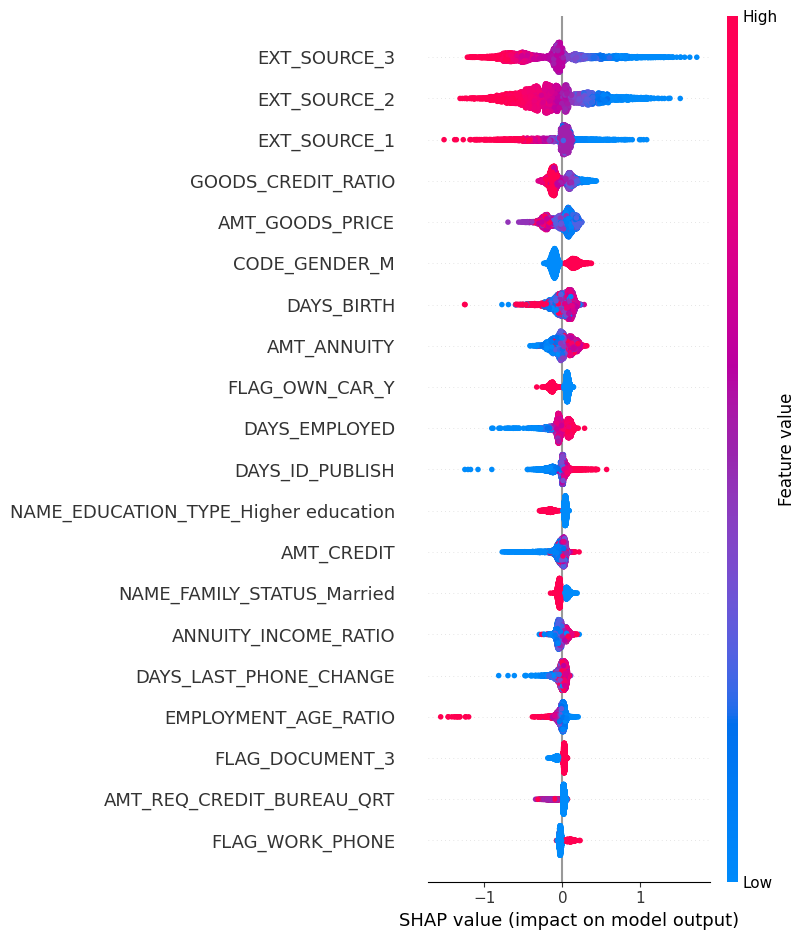

In [12]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.show()


**Interpretation:**
* Higher-ranked features have the greatest influence on Probability of Default predictions.
* Features appearing at the top of the plot are the most important risk drivers.


### Section 8: SHAP Bar Plot
Provides a ranked list of feature importance.


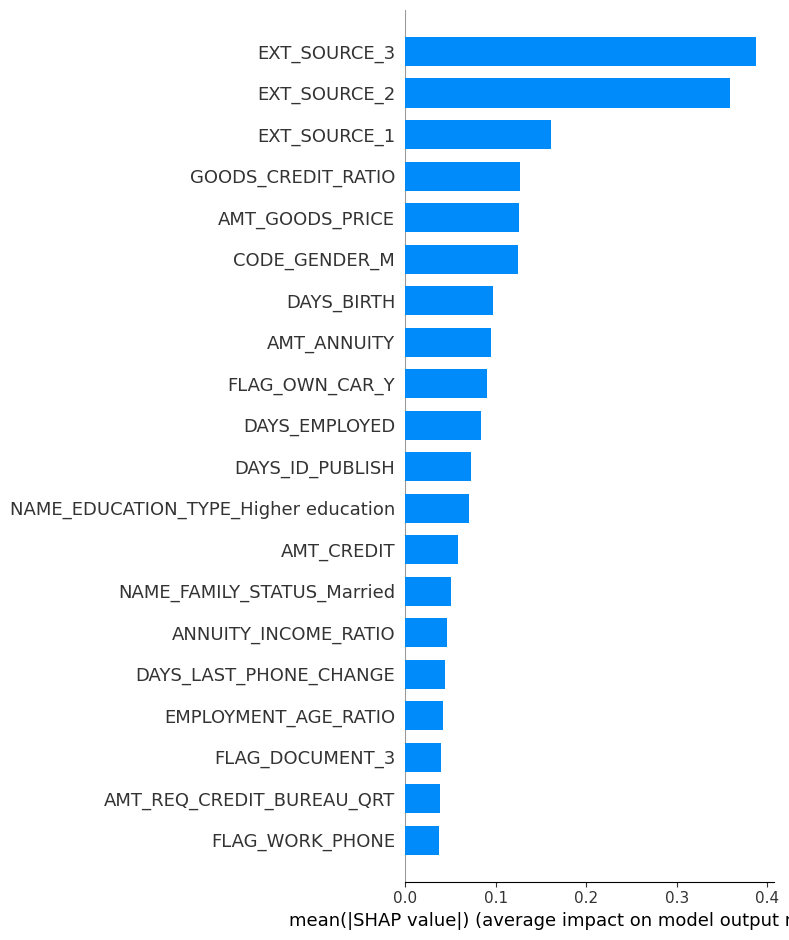

In [13]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.show()


**Interpretation:**
This visualization identifies the strongest predictors of default risk across the entire population.


### Section 9: Top 20 Important Features Table


In [14]:
shap_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(by="Importance", ascending=False)
shap_importance.head(20)


,Feature,Importance
29,EXT_SOURCE_3,0.387607
28,EXT_SOURCE_2,0.359090
27,EXT_SOURCE_1,0.160850
91,GOODS_CREDIT_RATIO,0.127245
5,AMT_GOODS_PRICE,0.125384
95,CODE_GENDER_M,0.124502
7,DAYS_BIRTH,0.096893
4,AMT_ANNUITY,0.094642
97,FLAG_OWN_CAR_Y,0.090980
8,DAYS_EMPLOYED,0.083842


### Section 10: Visualize Top Features


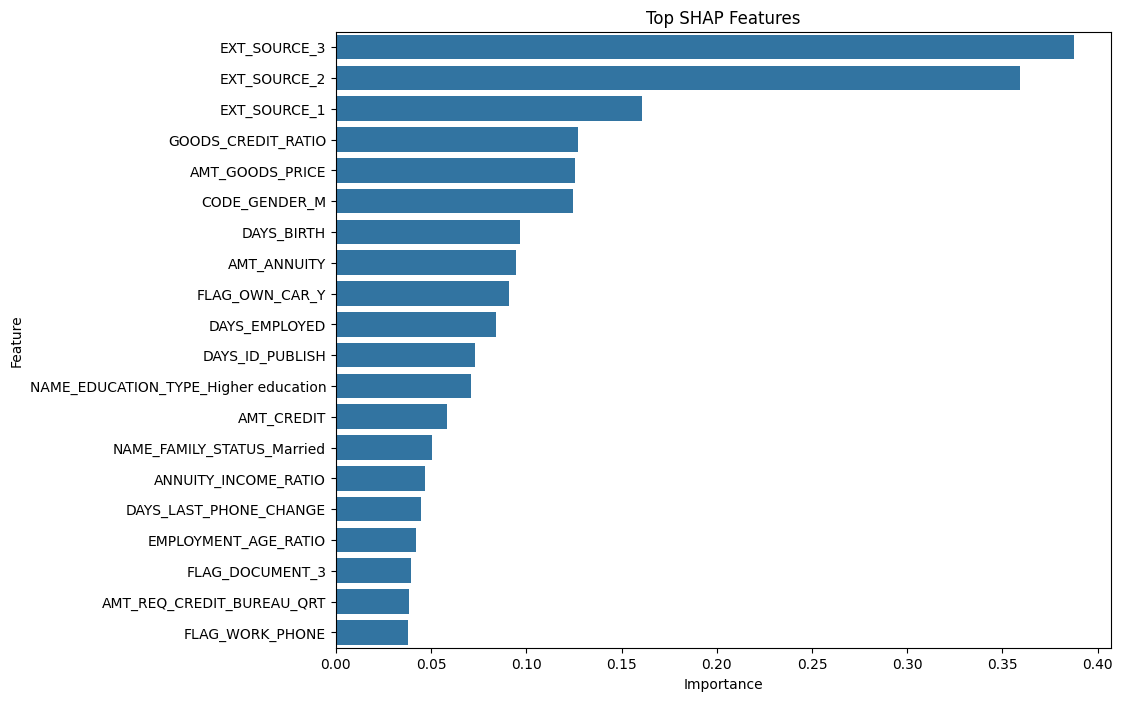

In [15]:
top_features = shap_importance.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top SHAP Features")
plt.show()


### Section 11: Dependence Plot
Analyze how specific features impact risk (e.g., `EXT_SOURCE_2`).


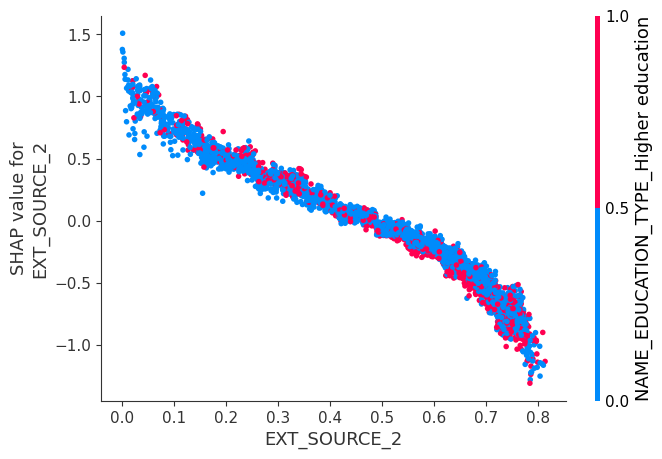

In [16]:
shap.dependence_plot("EXT_SOURCE_2", shap_values, X_sample)


*Tip: You can test additional features below, such as:*
* `EXT_SOURCE_3`
* `AMT_CREDIT`
* `AMT_INCOME_TOTAL`
* `CREDIT_INCOME_RATIO`
* `ANNUITY_INCOME_RATIO`


### Section 12: Local Explanation for One Customer


In [17]:
customer_index = 10
X_sample.iloc[customer_index]


SK_ID_CURR                           134561
CNT_CHILDREN                              4
AMT_INCOME_TOTAL                    67500.0
AMT_CREDIT                         331920.0
AMT_ANNUITY                         17077.5
                                     ...   
WALLSMATERIAL_MODE_Others             False
WALLSMATERIAL_MODE_Panel               True
WALLSMATERIAL_MODE_Stone, brick       False
WALLSMATERIAL_MODE_Wooden             False
EMERGENCYSTATE_MODE_Yes               False
Name: 29765, Length: 215, dtype: object

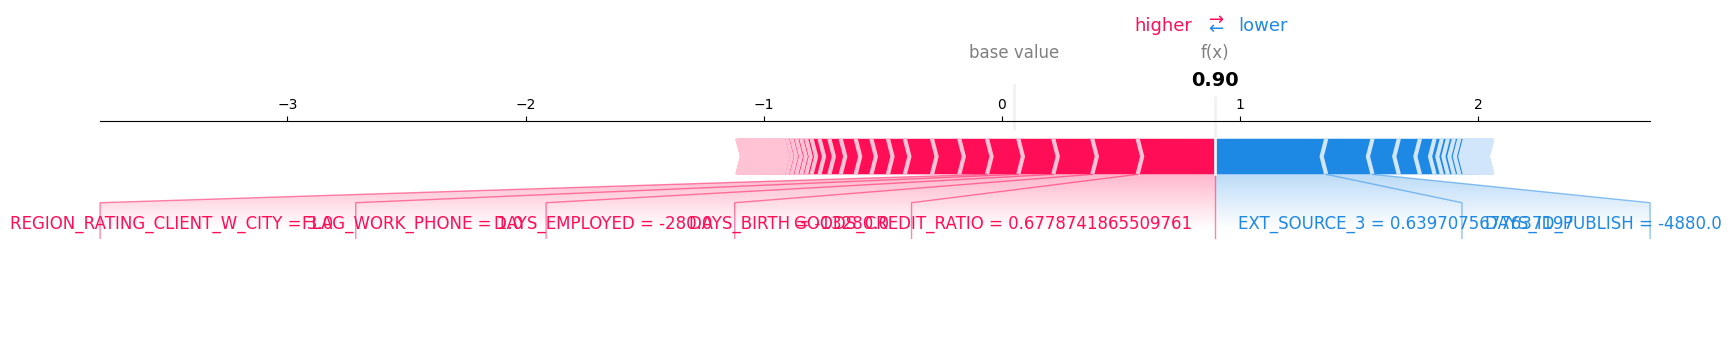

In [18]:
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_sample.iloc[customer_index],
    matplotlib=True
)


**Interpretation:**
The force plot explains:
* Why this customer received a specific risk score.
* Which variables pushed risk upward.
* Which variables reduced risk.


### Section 13: Explain High-Risk Customers
Identify highest predicted probabilities to simulate a credit analyst reviewing risky loan applications.


In [19]:
predictions = pd.read_csv("../artifacts/test_predictions.csv")

predictions.sort_values(by="predicted_probability", ascending=False).head(10)


,actual,predicted_probability,predicted_class
15338,1,0.958818,1
12341,1,0.954025,1
708,1,0.950311,1
34712,1,0.948878,1
10861,0,0.948194,1
4908,1,0.946757,1
24897,1,0.945265,1
12715,1,0.942729,1
18159,1,0.942508,1
59149,1,0.942494,1


### Section 14: Explain Low-Risk Customers
Compare patterns against high-risk clusters.


In [20]:
predictions.sort_values(by="predicted_probability", ascending=True).head(10)


,actual,predicted_probability,predicted_class
53785,0,0.003591,0
15224,0,0.004810,0
18018,0,0.005394,0
9506,1,0.006343,0
31403,0,0.006566,0
11175,0,0.006613,0
28975,0,0.007484,0
51028,0,0.008115,0
4800,0,0.008400,0
23021,0,0.008715,0


### Section 15: Save SHAP Feature Importance


In [21]:
shap_importance.to_csv("../artifacts/shap_feature_importance.csv", index=False)


### Section 16: Business Insights

#### Key Risk Drivers
Based on SHAP analysis, the strongest drivers of default risk typically include:
* External credit scores
* Credit burden indicators
* Income-related variables
* Employment characteristics
* Financial capacity indicators

#### Why SHAP Matters
Traditional feature importance indicates *which* variables matter. SHAP explains:
* How much each variable contributes.
* Whether it increases risk.
* Whether it decreases risk.

This provides transparency and supports model governance.


### Section 17: Business Interpretation

#### High-Risk Borrowers
Often exhibit:
* Low external credit scores.
* High debt burden.
* Lower income levels.
* Unstable employment patterns.

#### Low-Risk Borrowers
Often exhibit:
* Strong external scores.
* Stable income.
* Lower repayment burden.
* Longer employment history.


### Section 18: Model Governance Perspective
In banking environments, explainability supports:
* Regulatory compliance.
* Model validation.
* Internal audit requirements.
* Credit policy reviews.
* Risk committee reporting.

Explainability is frequently mandatory for production credit-risk systems.


### Deliverables
* ✓ SHAP Explainability
* ✓ Global Feature Importance
* ✓ Local Feature Importance
* ✓ Dependence Plots
* ✓ Force Plot Explanations
* ✓ Top Risk Drivers
* ✓ Business Interpretation
* ✓ Explainable AI Analysis
* ✓ Saved SHAP Feature Importance

**Output Files:** `artifacts/shap_feature_importance.csv`

### Key Outcome
The model is no longer a black box. Risk analysts can understand why customers are classified as risky, which variables drive predictions, and how model decisions align with business expectations. This notebook transforms the project into a production-oriented credit-risk solution suitable for banking and fintech environments.
